In [11]:
import torch
from torchvision import datasets, transforms,models
from torch.utils.data import DataLoader,random_split,Subset
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np 
import random
from sklearn.model_selection import train_test_split
import os
from PIL import Image

In [3]:
dataset_path = "dataset/CROP+MERGED"

train_path = dataset_path + "/train"
test_path = "dataset/test"


In [7]:
augmentation_list = {

    "No Augmentation": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Basic": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Color": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),
        transforms.ToTensor()
    ]),

    "Crop": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),
        transforms.ToTensor()
    ]),

    "Full without Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic + Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ])
}




augmentation_count = {

    "No Augmentation": 0,

    "Basic": 2,

    "Color": 1,

    "Crop": 1,

    "Full without Color": 3,

    "Full + Basic": 5,

    "Full + Basic + Color": 6,

    "Full": 4
}



test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])



seeds = [42, 10, 20]

results = []



for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("=" * 70)

        # -----------------------------
        # Set Seed
        # -----------------------------

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        

        full_train_dataset = datasets.ImageFolder(
            train_path,
            transform=None
        )

        labels = full_train_dataset.targets

        train_indices, val_indices = train_test_split(
            range(len(full_train_dataset)),
            test_size=0.2,
            stratify=labels,
            random_state=42
        )

        train_dataset = datasets.ImageFolder(
            train_path,
            transform=train_transform
        )

        val_dataset = datasets.ImageFolder(
            train_path,
            transform=test_transform
        )

        train_dataset = Subset(
            train_dataset,
            train_indices
        )

        val_dataset = Subset(
            val_dataset,
            val_indices
        )


        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=32,
            shuffle=False
        )

        

        model = models.resnet18(weights="DEFAULT")

        for param in model.parameters():
            param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = True

        model.fc = nn.Linear(
            model.fc.in_features,
            8
        )


        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam([
            {
                "params": model.layer4.parameters(),
                "lr": 0.0001
            },
            {
                "params": model.fc.parameters(),
                "lr": 0.001
            }
        ])


        best_val_accuracy = 0
        patience = 20
        counter = 0

        best_model_state = None

        for epoch in range(150):

            model.train()

            total_loss = 0

            for images, labels in train_loader:

                optimizer.zero_grad()

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

            train_loss = total_loss / len(train_loader)

            

            model.eval()

            correct = 0
            total = 0
            val_total_loss = 0

            with torch.no_grad():

                for images, labels in val_loader:

                    outputs = model(images)

                    loss = criterion(
                        outputs,
                        labels
                    )

                    val_total_loss += loss.item()

                    _, predicted = torch.max(
                        outputs,
                        1
                    )

                    total += labels.size(0)

                    correct += (
                        predicted == labels
                    ).sum().item()

            val_loss = val_total_loss / len(val_loader)

            val_accuracy = correct / total

            print(
                f"Epoch [{epoch+1}], "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val Accuracy: {val_accuracy:.4f}"
            )


            if val_accuracy > best_val_accuracy:

                best_val_accuracy = val_accuracy

                counter = 0

                best_model_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }

            else:

                counter += 1

                if counter >= patience:
                    break

       

        results.append({
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count": augmentation_count[
                augmentation_name
            ],
            "model_state": best_model_state
        })

        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )




best_result = results[0]

for result in results:

    if result["best_val_accuracy"] > best_result["best_val_accuracy"]:

        best_result = result

    elif (
        result["best_val_accuracy"]
        == best_result["best_val_accuracy"]
    ):

        if (
            result["augmentation_count"]
            > best_result["augmentation_count"]
        ):

            best_result = result




print("\n" + "=" * 70)
print("ALL RESULTS")
print("=" * 70)

for result in results:

    print(
        f"{result['augmentation']:25s} | "
        f"Seed: {result['seed']} | "
        f"Val: {result['best_val_accuracy'] * 100:.2f}% | "
        f"Augmentations: {result['augmentation_count']}"
    )



print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    f"Augmentation: "
    f"{best_result['augmentation']}"
)

print(
    f"Seed: "
    f"{best_result['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_result['best_val_accuracy'] * 100:.2f}%"
)

print(
    f"Number of Augmentations: "
    f"{best_result['augmentation_count']}"
)

torch.save(
    best_result["model_state"],
    "BEST_MODEL_Cleaned_Dataset.pth"
)


print("\nBEST_MODEL.pth saved successfully.")






Augmentation: No Augmentation
Seed: 42
Epoch [1], Train Loss: 0.6121, Val Loss: 0.2409, Val Accuracy: 0.9113
Epoch [2], Train Loss: 0.0977, Val Loss: 0.2103, Val Accuracy: 0.9293
Epoch [3], Train Loss: 0.0255, Val Loss: 0.1945, Val Accuracy: 0.9349
Epoch [4], Train Loss: 0.0100, Val Loss: 0.1967, Val Accuracy: 0.9405
Epoch [5], Train Loss: 0.0055, Val Loss: 0.1786, Val Accuracy: 0.9450
Epoch [6], Train Loss: 0.0037, Val Loss: 0.1811, Val Accuracy: 0.9428
Epoch [7], Train Loss: 0.0036, Val Loss: 0.2089, Val Accuracy: 0.9439
Epoch [8], Train Loss: 0.0032, Val Loss: 0.2079, Val Accuracy: 0.9416
Epoch [9], Train Loss: 0.0039, Val Loss: 0.1896, Val Accuracy: 0.9450
Epoch [10], Train Loss: 0.0013, Val Loss: 0.2042, Val Accuracy: 0.9428
Epoch [11], Train Loss: 0.0089, Val Loss: 0.3035, Val Accuracy: 0.9360
Epoch [12], Train Loss: 0.0213, Val Loss: 0.3855, Val Accuracy: 0.9248
Epoch [13], Train Loss: 0.0482, Val Loss: 0.4261, Val Accuracy: 0.9102
Epoch [14], Train Loss: 0.0511, Val Loss: 0.26

In [6]:
test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    test_path,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [7]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    8
)

model.load_state_dict(
    torch.load(
        "BEST_MODEL_Cleaned_Dataset.pth",
        map_location="cpu"
    )
)

model.eval()


all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_accuracy = (all_labels == all_predictions).mean()

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 96.25%

Classification Report:
              precision    recall  f1-score   support

   ambulance       1.00      0.94      0.97        50
     autobus       1.00      1.00      1.00        50
      kamyun       0.96      0.86      0.91        50
    kamyunet       0.87      0.96      0.91        50
     minibus       0.98      1.00      0.99        50
      savari       1.00      0.96      0.98        50
        taxi       1.00      0.98      0.99        50
       vanet       0.91      1.00      0.95        50

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



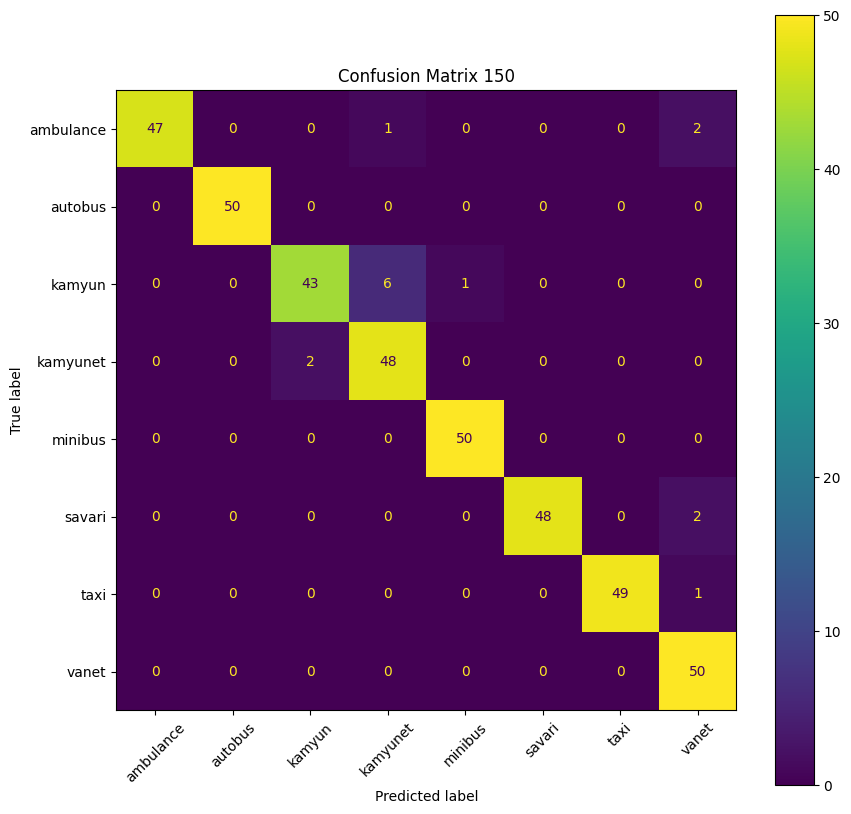

In [8]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(f"Confusion Matrix {images.shape[-1]}")
plt.show()

In [9]:
wrong_predictions = []

start_index = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                wrong_predictions.append({
                    "index": start_index + i,
                    "true_class": test_dataset.classes[
                        labels[i].item()
                    ],
                    "predicted_class": test_dataset.classes[
                        predicted[i].item()
                    ],
                    "confidence": confidence[i].item()
                })

        start_index += len(labels)


print("=" * 80)
print("WRONG PREDICTIONS")
print("=" * 80)

print(
    f"Number of wrong predictions: "
    f"{len(wrong_predictions)}"
)

for item in wrong_predictions:

    print(
        f"Index: {item['index']} | "
        f"True: {item['true_class']} | "
        f"Predicted: {item['predicted_class']} | "
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

WRONG PREDICTIONS
Number of wrong predictions: 15
Index: 0 | True: ambulance | Predicted: vanet | Confidence: 97.01%
Index: 19 | True: ambulance | Predicted: vanet | Confidence: 97.97%
Index: 40 | True: ambulance | Predicted: kamyunet | Confidence: 77.16%
Index: 108 | True: kamyun | Predicted: kamyunet | Confidence: 100.00%
Index: 109 | True: kamyun | Predicted: kamyunet | Confidence: 99.75%
Index: 112 | True: kamyun | Predicted: kamyunet | Confidence: 100.00%
Index: 114 | True: kamyun | Predicted: kamyunet | Confidence: 99.96%
Index: 134 | True: kamyun | Predicted: kamyunet | Confidence: 91.07%
Index: 143 | True: kamyun | Predicted: kamyunet | Confidence: 94.13%
Index: 147 | True: kamyun | Predicted: minibus | Confidence: 84.28%
Index: 197 | True: kamyunet | Predicted: kamyun | Confidence: 62.15%
Index: 199 | True: kamyunet | Predicted: kamyun | Confidence: 83.91%
Index: 287 | True: savari | Predicted: vanet | Confidence: 67.91%
Index: 293 | True: savari | Predicted: vanet | Confidenc

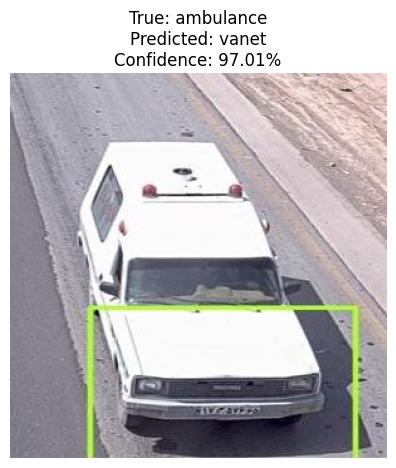

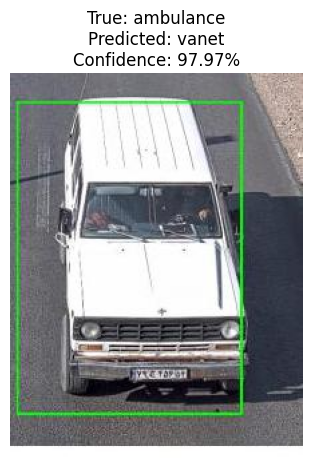

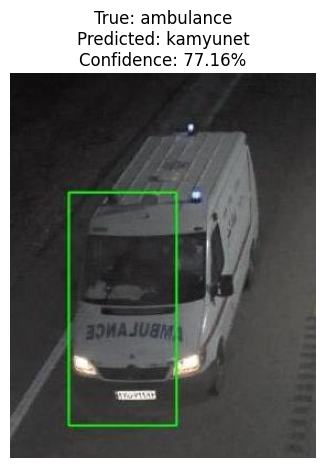

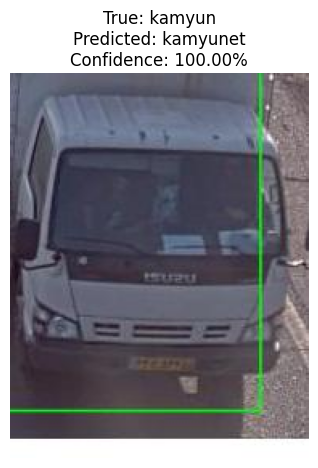

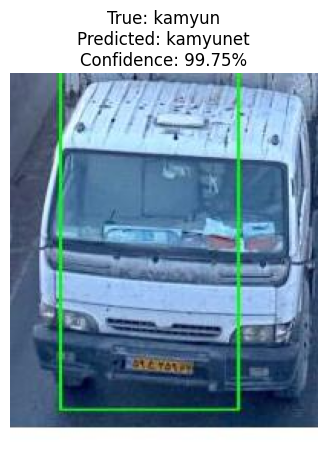

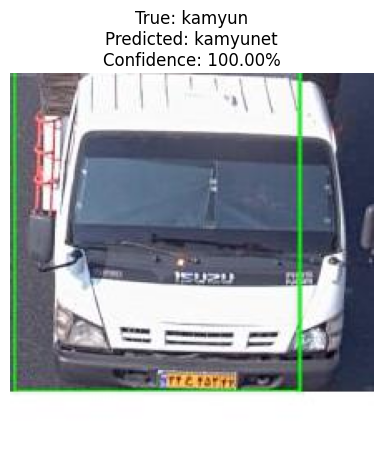

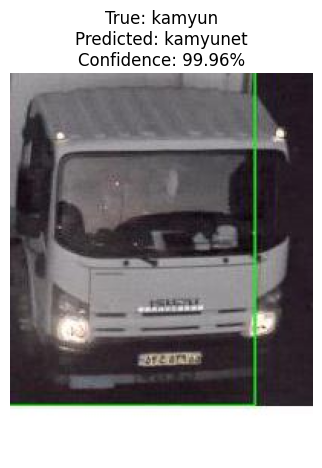

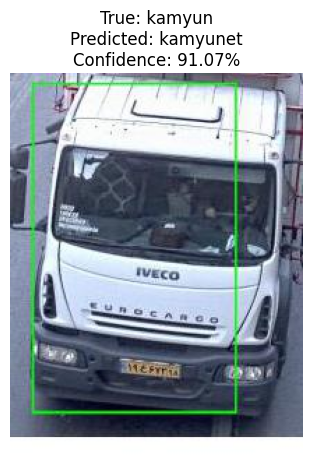

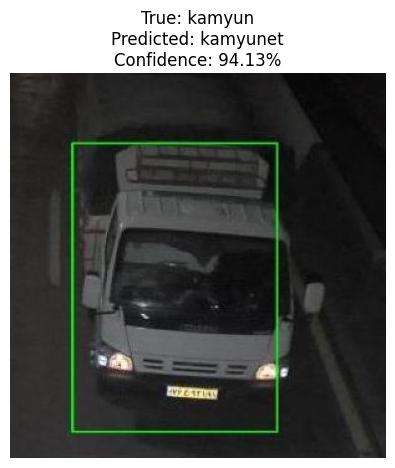

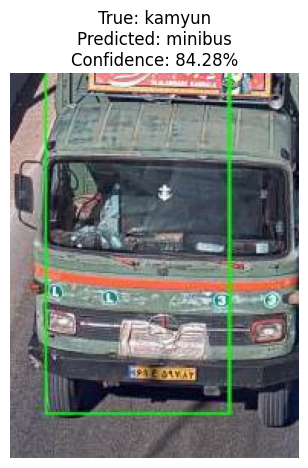

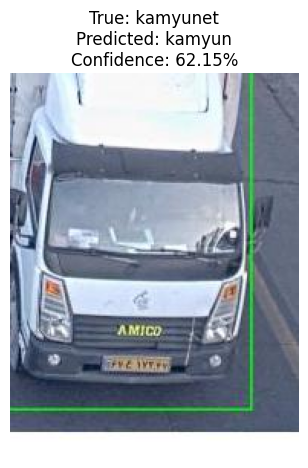

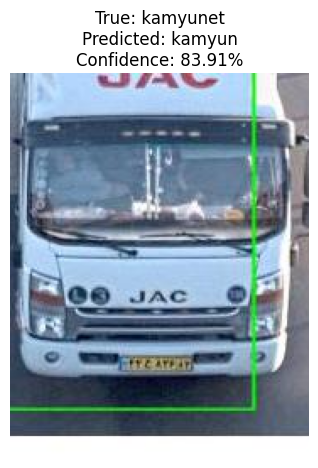

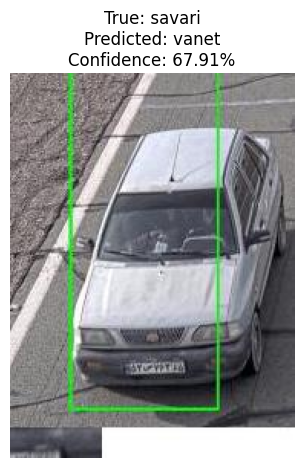

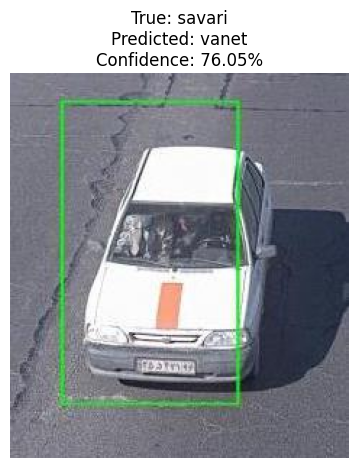

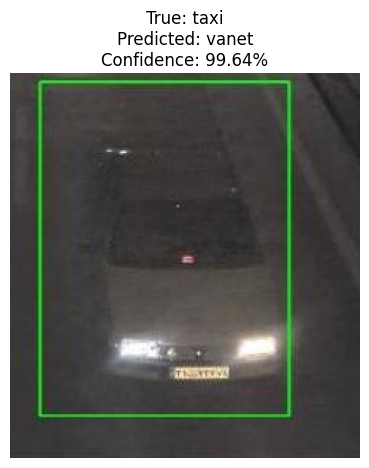

In [12]:
for item in wrong_predictions:

    index = item["index"]

    image_path, _ = test_dataset.samples[index]

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.title(
        f"True: {item['true_class']}\n"
        f"Predicted: {item['predicted_class']}\n"
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

    plt.axis("off")

    plt.show()